In [1]:
import sys
!{sys.executable} -m pip install scikit-learn xgboost

In [8]:
import pandas as pd

# 1. Cargar el dataset de 10,000 registros
# Si te marca error de archivo no encontrado, asegúrate de que el nombre sea exacto
df = pd.read_csv("../data/raw/registro_rendimiento.csv")

# 2. Limpieza básica (quitar filas vacías si es que hubo algún micro-corte)
df = df.dropna()

# 3. Mostrar la estructura de los datos para verificar
print(f"Total de registros listos: {len(df)}")
display(df.head()) # Esto mostrará una tabla bonita con tus primeros 5 registros

Total de registros listos: 10000


,Timestamp,CPU_Percent,RAM_Utilizada_MB,RAM_Libre_MB,RAM_Percent,Latencia_ms
0,2026-05-21 04:34:49,100.0,223.49,1274.00,22.4,0.22
1,2026-05-21 04:34:54,0.0,224.41,1273.07,22.5,0.12
2,2026-05-21 04:34:59,0.1,224.41,1273.07,22.5,0.10
3,2026-05-21 04:35:04,0.1,225.38,1272.11,22.5,0.15
4,2026-05-21 04:35:09,0.0,225.37,1272.11,22.5,0.11


In [9]:
import pandas as pd

# Mostrar si hay valores nulos en el dataset
print("Valores nulos antes de la limpieza:")
print(df.isnull().sum())

# Eliminar cualquier fila que tenga valores nulos o vacíos
df = df.dropna()

print(f"\nTotal de registros después de limpieza: {len(df)}")

Valores nulos antes de la limpieza:
Timestamp           0
CPU_Percent         0
RAM_Utilizada_MB    0
RAM_Libre_MB        0
RAM_Percent         0
Latencia_ms         0
dtype: int64

Total de registros después de limpieza: 10000


In [10]:
# Convertir la columna Timestamp a formato datetime de Pandas
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Opcional pero muy recomendado: convertir a una variable numérica continua (segundos)
# Esto le sirve muchísimo a algoritmos como XGBoost o Random Forest
df['Timestamp_Num'] = df['Timestamp'].astype('int64') // 10**9 

# Ver los tipos de datos para confirmar que ya no es un "object" (texto)
print(df.dtypes)

Timestamp           datetime64[us]
CPU_Percent                float64
RAM_Utilizada_MB           float64
RAM_Libre_MB               float64
RAM_Percent                float64
Latencia_ms                float64
Timestamp_Num                int64
dtype: object


In [20]:
# 1. Primero, veamos qué nombres de columnas existen realmente en tu DataFrame
print("Nombres de columnas disponibles:", df.columns.tolist())

# 3. Ahora sí, creamos la columna de futuro usando 'Latencia' (que ya debería existir)
df['Latencia_Futura_30s'] = df['Latencia_ms'].shift(-6)

# 4. Limpiamos vacíos
df = df.dropna()

# 5. Verificamos
display(df[['Timestamp', 'CPU_Percent', 'Latencia_ms', 'Latencia_Futura_30s']].head(10))


Nombres de columnas disponibles: ['Timestamp', 'CPU_Percent', 'RAM_Utilizada_MB', 'RAM_Libre_MB', 'RAM_Percent', 'Latencia_ms', 'Latencia_Futura_30s']


,Timestamp,CPU_Percent,Latencia_ms,Latencia_Futura_30s
0,2026-05-21 04:34:49,100.0,0.22,0.16
1,2026-05-21 04:34:54,0.0,0.12,0.14
2,2026-05-21 04:34:59,0.1,0.10,0.10
3,2026-05-21 04:35:04,0.1,0.15,0.11
4,2026-05-21 04:35:09,0.0,0.11,0.16
5,2026-05-21 04:35:14,0.0,0.16,0.15
6,2026-05-21 04:35:19,0.1,0.16,0.18
7,2026-05-21 04:35:24,0.1,0.14,0.18
8,2026-05-21 04:35:29,0.1,0.10,0.11
9,2026-05-21 04:35:34,0.0,0.11,0.15


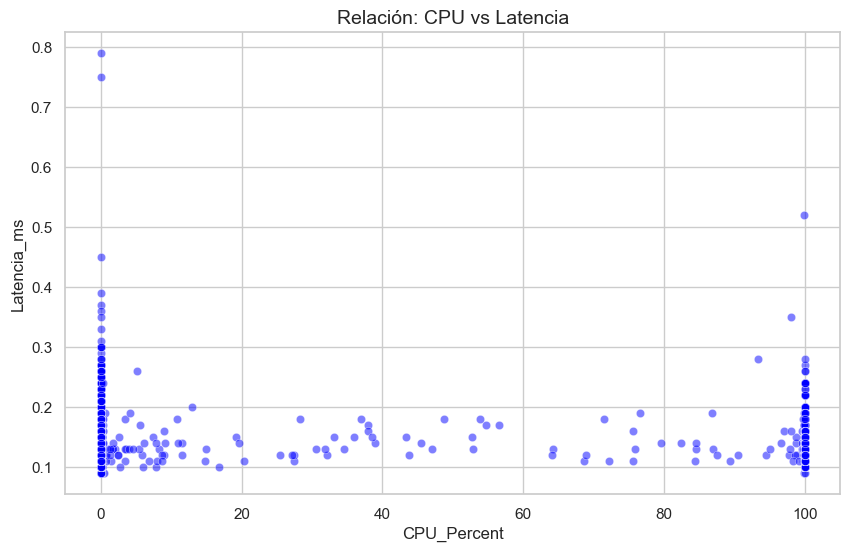

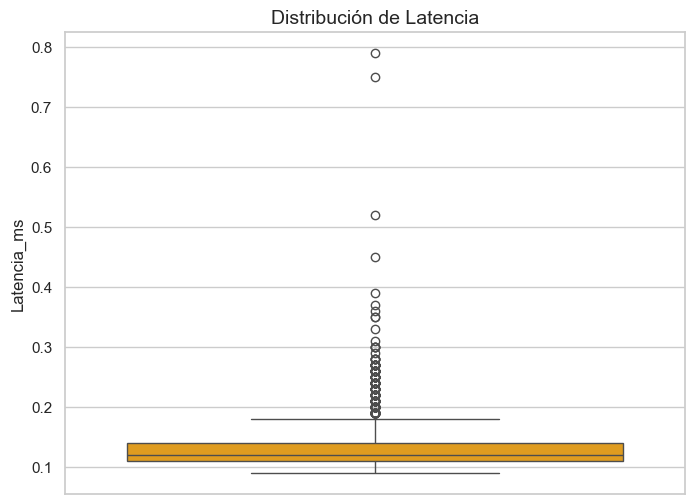

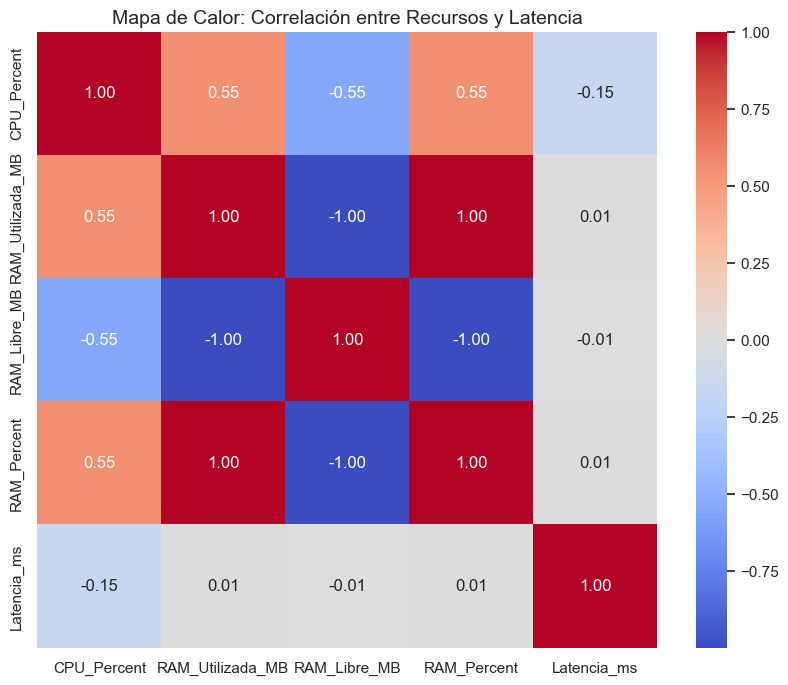

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_theme(style="whitegrid")

# --- GRÁFICA 1: Dispersión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CPU_Percent', y='Latencia_ms', data=df, color='blue', alpha=0.5)
plt.title('Relación: CPU vs Latencia', fontsize=14)
plt.show()

# --- GRÁFICA 2: Boxplot (Outliers) ---
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Latencia_ms'], color='orange')
plt.title('Distribución de Latencia', fontsize=14)
plt.show()

# --- GRÁFICA 3: Mapa de Calor (La que faltaba) ---
# Seleccionamos solo las columnas numéricas que tienen sentido correlacionar
cols_corr = ['CPU_Percent', 'RAM_Utilizada_MB', 'RAM_Libre_MB', 'RAM_Percent', 'Latencia_ms']

plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlación entre Recursos y Latencia', fontsize=14)
plt.show()

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- FASE 1: INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING) ---

# 1. Convertir la fecha a formato numérico (Timestamp_Num)
# La IA no lee fechas, así que las convertimos a segundos matemáticos.
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Timestamp_Num'] = df['Timestamp'].astype('int64') // 10**9

# 2. Crear la máquina del tiempo: Latencia_Futura_30s
# Como tomaste datos cada 5 segundos, 30 segundos equivalen a 6 renglones de diferencia (5 * 6 = 30).
# Usamos shift(-6) para recorrer los valores del futuro y ponerlos en el presente.
df['Latencia_Futura_30s'] = df['Latencia_ms'].shift(-6)

# 3. Limpiar los vacíos
# Los últimos 6 registros del archivo no tendrán futuro para predecir, así que los borramos.
df = df.dropna()

# ========== FASE 3: DIVISIÓN TEMPORAL (sin barajar) ==========

# Asegurar orden cronológico (tu CSV ya lo está, pero no está de más)
df = df.sort_values('Timestamp')

# Características y objetivo (mismas que antes)
columnas_features = ['CPU_Percent', 'RAM_Utilizada_MB', 'RAM_Libre_MB', 'RAM_Percent', 'Timestamp_Num']

# Punto de corte: 80% del tiempo para entrenar, 20% final para probar
split_index = int(len(df) * 0.8)

# Entrenamiento = pasado (primeros 80%)
train_df = df.iloc[:split_index]
# Prueba = futuro (último 20%)
test_df = df.iloc[split_index:]

X_train = train_df[columnas_features]
y_train = train_df['Latencia_Futura_30s']

X_test = test_df[columnas_features]
y_test = test_df['Latencia_Futura_30s']

print(f"Entrenamiento: {train_df['Timestamp'].min()} → {train_df['Timestamp'].max()}")
print(f"Prueba:        {test_df['Timestamp'].min()} → {test_df['Timestamp'].max()}")
print(f"Tamaños: {X_train.shape[0]} entrenamiento, {X_test.shape[0]} prueba")

Entrenamiento: 2026-05-21 04:34:49 → 2026-05-21 18:08:48
Prueba:        2026-05-21 18:08:53 → 2026-05-21 21:23:09
Tamaños: 7976 entrenamiento, 1994 prueba


In [25]:
# ================== ENTRENAMIENTO Y EVALUACIÓN ==================
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Entrenar Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 2. Entrenar XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# 3. Evaluación
def evaluar_modelo(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    print(f"\n--- {nombre} ---")
    print(f"RMSE (error cuadrático medio raíz): {rmse:.4f} ms")
    print(f"MAE (error absoluto medio):        {mae:.4f} ms")
    return rmse, mae

rmse_rf, mae_rf = evaluar_modelo("Random Forest", y_test, y_pred_rf)
rmse_xgb, mae_xgb = evaluar_modelo("XGBoost", y_test, y_pred_xgb)


--- Random Forest ---
RMSE (error cuadrático medio raíz): 0.0284 ms
MAE (error absoluto medio):        0.0197 ms

--- XGBoost ---
RMSE (error cuadrático medio raíz): 0.0290 ms
MAE (error absoluto medio):        0.0203 ms


In [26]:
from sklearn.metrics import r2_score

std_test = y_test.std()
media_test = y_test.mean()
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"Media de latencia futura:  {media_test:.4f} ms")
print(f"Desviación estándar:       {std_test:.4f} ms")
print(f"R² Random Forest: {r2_rf:.4f}")
print(f"R² XGBoost:      {r2_xgb:.4f}")

Media de latencia futura:  0.1299 ms
Desviación estándar:       0.0272 ms
R² Random Forest: -0.0928
R² XGBoost:      -0.1390


In [27]:
# Calcular umbral con el conjunto de entrenamiento (pasado)
umbral = y_train.mean() + 2 * y_train.std()
print(f"Umbral de pico: {umbral:.4f} ms")

# Clasificar el conjunto de prueba según ese umbral
y_test_spike = (y_test > umbral).astype(int)
y_pred_xgb_spike = (y_pred_xgb > umbral).astype(int)
y_pred_rf_spike = (y_pred_rf > umbral).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Clasificación de Picos con XGBoost ---")
print(classification_report(y_test_spike, y_pred_xgb_spike, target_names=['Normal', 'Pico']))
print("Matriz de confusión:")
print(confusion_matrix(y_test_spike, y_pred_xgb_spike))

Umbral de pico: 0.1821 ms

--- Clasificación de Picos con XGBoost ---
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98      1931
        Pico       0.00      0.00      0.00        63

    accuracy                           0.97      1994
   macro avg       0.48      0.50      0.49      1994
weighted avg       0.94      0.97      0.95      1994

Matriz de confusión:
[[1931    0]
 [  63    0]]


c:\Users\wissw\Desktop\Proyecto_ML_Latencia\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\wissw\Desktop\Proyecto_ML_Latencia\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\wissw\Desktop\Proyecto_ML_Latencia\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"